# Training dataset — deep dive

**Scope**
- `datasets/training` only (class folders at dataset root)
- Integrity, duration, waveform scalars, CQT-derived spectral / label metrics
- Outliers and within-dataset near-duplicates

**Out of scope**
- Onset / multi-onset analysis
- Cross-dataset comparison (see sibling notebooks under `vivo/`, `thinkpad/`)
- Re-running CQT extraction or model training

**Artifacts**
- `datasets/training-dataset-info.pkl` — duration inventory (rebuild only if missing)
- `features/training.npz` — cached CQT `(N, 216, 188)`
- Metrics cache: `datasets/training-sample-metrics.pkl`

In [3]:
from os import path, listdir
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from tqdm.notebook import tqdm
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# --- per-dataset config (this notebook is under notebooks/training/) ---
DATASET = "training"
# feature cache filename for this dataset
FEATURES_NAME = "training.npz"

DATASET_DIR = path.normpath(f"../../datasets/{DATASET}")
SOURCE_PATH = DATASET_DIR
TRAIN_DIR = DATASET_DIR
INVENTORY_PATH = path.normpath(f"../../datasets/{DATASET}-dataset-info.pkl")
FEATURES_PATH = path.normpath(f"../../features/{FEATURES_NAME}")
METRICS_PATH = path.normpath(f"../../datasets/{DATASET}-sample-metrics.pkl")

AUDIO_SAMPLE_RATE = 48_000
CQT_HOP_LENGTH = 512
CQT_BINS_PER_OCTAVE = 36
CQT_OCTAVES = 6
CQT_FMIN = librosa.note_to_hz("C1")
CQT_FEATURE_FRAMES = round(2.0 * AUDIO_SAMPLE_RATE / CQT_HOP_LENGTH)  # 188
CQT_FLOOR_DB = -80.0

BOXPROPS = dict(color="#01696f", linewidth=1.4)
WHISKERPROPS = dict(color="#01696f", linewidth=1.2, linestyle="--")
MEDIANPROPS = dict(color="#da7101", linewidth=2)
FLIERPROPS = dict(
    marker="o", markerfacecolor="#a12c7b", markersize=4, linestyle="none", alpha=0.6
)

display(pd.DataFrame([
    {"key": "dataset", "value": DATASET},
    {"key": "dataset_dir", "value": DATASET_DIR},
    {"key": "features", "value": FEATURES_PATH},
    {"key": "metrics_cache", "value": METRICS_PATH},
    {"key": "cqt_feature_frames (2s)", "value": CQT_FEATURE_FRAMES},
    {"key": "audio_sample_rate", "value": AUDIO_SAMPLE_RATE},
]))

,key,value
0,train_dir,../datasets/training
1,features,../features/training.npz
2,metrics_cache,../datasets/training-sample-metrics.pkl
3,cqt_feature_frames (2s),188
4,audio_sample_rate,48000


## 1. Inventory & duration

Load the existing duration inventory if present; otherwise scan training audio once.
Parse class names into root / quality / octave and keep **training only**.

In [6]:
def scan_dataset_inventory(source_path: str) -> pd.DataFrame:
    """Walk dataset/{class}/* audio files and record durations."""
    records = []
    dataset_type = path.basename(source_path)
    for class_name in tqdm(listdir(source_path), desc=f"  {dataset_type}"):
        class_path = path.join(source_path, class_name)
        if not path.isdir(class_path):
            continue
        for audio_file in listdir(class_path):
            audio_path = path.join(class_path, audio_file)
            if not path.isfile(audio_path):
                continue
            try:
                duration = librosa.get_duration(path=audio_path)
                records.append(
                    {
                        "dataset_type": dataset_type,
                        "class_name": class_name,
                        "filename": audio_file,
                        "duration_s": duration,
                    }
                )
            except Exception as e:
                display(Markdown(f"**WARN** Could not read `{audio_path}`: {e}"))
    return pd.DataFrame(records)


def parse_class_name(name: str) -> pd.Series:
    m = re.match(r"^([A-G]#?)_(major|minor|diminished)_(\d+)$", name)
    if not m:
        return pd.Series({"root": None, "quality": None, "octave": None})
    return pd.Series(
        {"root": m.group(1), "quality": m.group(2), "octave": int(m.group(3))}
    )


def file_index(filename: str):
    m = re.search(r"-(\d+)\.(ogg|wav)$", filename, re.I)
    return int(m.group(1)) if m else np.nan


if path.exists(INVENTORY_PATH):
    inventory = pd.read_pickle(INVENTORY_PATH)
    display(Markdown(f"Loaded inventory from `{INVENTORY_PATH}` (**{len(inventory)}** rows)"))
else:
    inventory = scan_dataset_inventory(DATASET_DIR)
    inventory.to_pickle(INVENTORY_PATH)
    display(Markdown(f"Scanned and saved inventory to `{INVENTORY_PATH}` (**{len(inventory)}** rows)"))

# Keep rows for this dataset (also accept legacy split name "training" for old pkls)
df = inventory[inventory["dataset_type"] == DATASET].reset_index(drop=True)
meta = df["class_name"].apply(parse_class_name)
df = pd.concat([df, meta], axis=1)
df["file_idx"] = df["filename"].map(file_index)
df["audio_path"] = [
    path.join(DATASET_DIR, c, f) for c, f in zip(df["class_name"], df["filename"])
]

summary = pd.DataFrame([
    {"metric": "rows", "value": len(df)},
    {"metric": "n_classes", "value": df["class_name"].nunique()},
    {"metric": "parse_failures", "value": int(df["root"].isna().sum())},
    {"metric": "per_class_min", "value": int(df.groupby("class_name").size().min()) if len(df) else 0},
    {"metric": "per_class_max", "value": int(df.groupby("class_name").size().max()) if len(df) else 0},
])
display(Markdown(f"### {DATASET} inventory summary"))
display(summary)
display(Markdown("### Sample rows"))
display(df.head(10))

Loaded inventory from `../datasets/training-dataset-info.pkl` (**10800** rows)

### Training inventory summary

,metric,value
0,training_rows,7200
1,n_classes,36
2,parse_failures,0
3,per_class_min,200
4,per_class_max,200


### Sample rows

,dataset_type,class_name,filename,duration_s,root,quality,octave,file_idx,audio_path
0,training,A#_diminished_4,A#_diminished_4-1.ogg,2.2000,A#,diminished,4,1,../datasets/training/A#_diminished_4/A#_d...
1,training,A#_diminished_4,A#_diminished_4-10.ogg,2.2000,A#,diminished,4,10,../datasets/training/A#_diminished_4/A#_d...
2,training,A#_diminished_4,A#_diminished_4-100.ogg,2.4000,A#,diminished,4,100,../datasets/training/A#_diminished_4/A#_d...
3,training,A#_diminished_4,A#_diminished_4-101.ogg,2.4000,A#,diminished,4,101,../datasets/training/A#_diminished_4/A#_d...
4,training,A#_diminished_4,A#_diminished_4-102.ogg,2.2000,A#,diminished,4,102,../datasets/training/A#_diminished_4/A#_d...
5,training,A#_diminished_4,A#_diminished_4-103.ogg,2.4000,A#,diminished,4,103,../datasets/training/A#_diminished_4/A#_d...
6,training,A#_diminished_4,A#_diminished_4-104.ogg,2.5000,A#,diminished,4,104,../datasets/training/A#_diminished_4/A#_d...
7,training,A#_diminished_4,A#_diminished_4-105.ogg,2.2000,A#,diminished,4,105,../datasets/training/A#_diminished_4/A#_d...
8,training,A#_diminished_4,A#_diminished_4-106.ogg,2.2000,A#,diminished,4,106,../datasets/training/A#_diminished_4/A#_d...
9,training,A#_diminished_4,A#_diminished_4-107.ogg,2.3000,A#,diminished,4,107,../datasets/training/A#_diminished_4/A#_d...


In [7]:
# --- Inventory integrity ---
class_counts = df.groupby("class_name").size().rename("n").reset_index()
quality_counts = df["quality"].value_counts().rename_axis("quality").reset_index(name="n")
root_counts = df["root"].value_counts().sort_index().rename_axis("root").reset_index(name="n")

idx_issues = []
for cls, g in df.groupby("class_name"):
    idxs = sorted(g.file_idx.dropna().astype(int).tolist())
    expected = list(range(1, len(idxs) + 1))
    if idxs != expected:
        missing = sorted(set(expected) - set(idxs))
        dups = [i for i, c in pd.Series(idxs).value_counts().items() if c > 1]
        idx_issues.append({"class_name": cls, "missing": missing, "dups": dups})

hygiene = pd.DataFrame([
    {"check": "file_index_issues", "value": len(idx_issues)},
    {"check": "filename_matches_class_prefix", "value": bool(df.apply(lambda r: r.filename.startswith(r.class_name), axis=1).all())},
    {"check": "all_audio_ext", "value": bool(df.filename.str.lower().str.endswith((".ogg", ".wav")).all())},
    {"check": "octaves", "value": sorted(df.octave.dropna().unique().tolist())},
    {"check": "roots", "value": sorted(df.root.dropna().unique().tolist())},
    {"check": "qualities", "value": sorted(df.quality.dropna().unique().tolist())},
    {"check": "unique_per_class_counts", "value": class_counts["n"].unique().tolist()},
])

display(Markdown("### Hygiene checks"))
display(hygiene)
display(Markdown("### Counts by quality"))
display(quality_counts)
display(Markdown("### Counts by root"))
display(root_counts)

# --- Duration summary ---
dur_desc = df["duration_s"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame("duration_s")
dur_hist = (
    df["duration_s"].round(6).value_counts().sort_index()
    .rename_axis("duration_s").reset_index(name="count")
)
dur_hist["share"] = dur_hist["count"] / dur_hist["count"].sum()

dur_vs_window = pd.DataFrame([
    {"check": "shorter_than_2.0s", "n": int((df.duration_s < 2.0).sum())},
    {"check": "exactly_2.0s", "n": int((df.duration_s == 2.0).sum())},
    {"check": "between_2.0_and_2.5s", "n": int(((df.duration_s >= 2.0) & (df.duration_s <= 2.5)).sum())},
    {"check": "longer_than_2.5s", "n": int((df.duration_s > 2.5).sum())},
    {"check": "unique_durations", "n": int(df.duration_s.nunique())},
])

cls_dur = (
    df.groupby("class_name")["duration_s"]
    .agg(n="count", min="min", mean="mean", median="median", max="max", std="std")
    .round(4)
    .sort_values("mean")
)
qual_dur = df.groupby("quality")["duration_s"].agg(["count", "min", "mean", "median", "max", "std"]).round(4)

display(Markdown("### Duration describe"))
display(dur_desc)
display(Markdown("### Duration histogram (discrete)"))
display(dur_hist)
display(Markdown("### Duration vs 2.0s model window"))
display(dur_vs_window)
display(Markdown("### Shortest / longest samples"))
display(df.nsmallest(5, "duration_s")[["class_name", "filename", "duration_s"]])
display(df.nlargest(5, "duration_s")[["class_name", "filename", "duration_s"]])
display(Markdown("### Duration by quality"))
display(qual_dur)
display(Markdown("### Class mean duration (shortest → longest)"))
display(cls_dur)

### Hygiene checks

,check,value
0,file_index_issues,0
1,filename_matches_class_prefix,True
2,all_ogg,True
3,octaves,[4]
4,roots,"[A, A#, B, C, C#, D, D#, E, F, F#, G, G#]"
5,qualities,"[diminished, major, minor]"
6,unique_per_class_counts,[200]


### Counts by quality

,quality,n
0,diminished,2400
1,major,2400
2,minor,2400


### Counts by root

...

,class_name,filename,duration_s
209,A#_major_4,A#_major_4-107.ogg,2.7000
343,A#_major_4,A#_major_4-48.ogg,2.7000
455,A#_minor_4,A#_minor_4-149.ogg,2.7000
493,A#_minor_4,A#_minor_4-183.ogg,2.7000
588,A#_minor_4,A#_minor_4-89.ogg,2.7000


### Duration by quality

,count,min,mean,median,max,std
quality,,,,,,
diminished,2400,2.1000,2.3970,2.4000,2.7000,0.1171
major,2400,2.0000,2.3946,2.4000,2.7000,0.1180
minor,2400,2.1000,2.3984,2.4000,2.7000,0.1161


### Class mean duration (shortest → longest)

,n,min,mean,median,max,std
class_name,,,,,,
F_diminished_4,200,2.1000,2.3820,2.4000,2.7000,0.1129
D#_minor_4,200,2.1000,2.3820,2.4000,2.7000,0.1177
C#_major_4,200,2.1000,2.3830,2.4000,2.6000,0.1161
A#_diminished_4,200,2.1000,2.3880,2.4000,2.6000,0.1176
C_major_4,200,2.1000,2.3880,2.4000,2.7000,0.1167
F_major_4,200,2.1000,2.3885,2.4000,2.7000,0.1233
E_diminished_4,200,2.1000,2.3885,2.4000,2.6000,0.1113
D#_major_4,200,2.1000,2.3895,2.4000,2.7000,0.1175
G#_diminished_4,200,2.1000,2.3900,2.4000,2.7000,0.1070


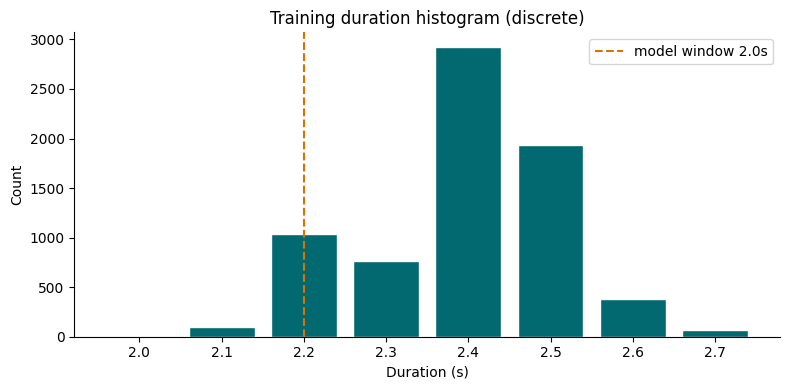

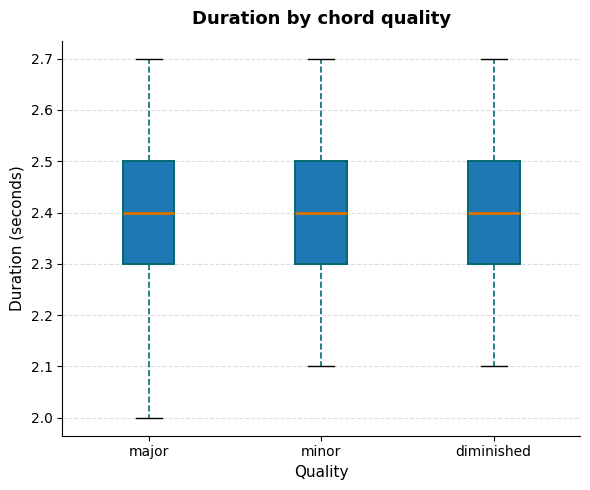

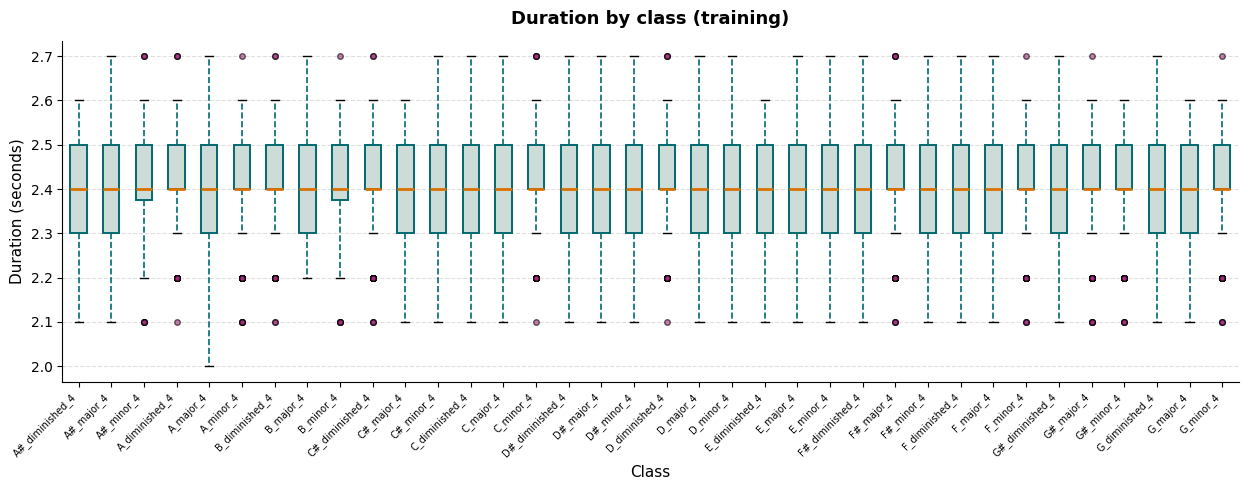

In [15]:
def _base_fig(n_groups, title, xlabel, ylabel="Duration (seconds)"):
    fig, ax = plt.subplots(figsize=(max(6, n_groups * 0.35), 5))
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    return fig, ax


# Duration histogram
fig, ax = plt.subplots(figsize=(8, 4))
vals = sorted(df["duration_s"].round(6).unique())
counts = df["duration_s"].round(6).value_counts().reindex(vals).fillna(0)
ax.bar([str(v) for v in vals], counts.values, color="#01696f", edgecolor="white")
ax.axvline(2.0, color="#da7101", linestyle="--", linewidth=1.5, label="model window 2.0s")
ax.set_title("Training duration histogram (discrete)")
ax.set_xlabel("Duration (s)")
ax.set_ylabel("Count")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Duration by quality
qualities = ["major", "minor", "diminished"]
data_q = [df.loc[df.quality == q, "duration_s"].values for q in qualities]
fig, ax = _base_fig(len(qualities), "Duration by chord quality", "Quality")
ax.boxplot(
    data_q,
    tick_labels=qualities,
    boxprops=BOXPROPS,
    whiskerprops=WHISKERPROPS,
    medianprops=MEDIANPROPS,
    flierprops=FLIERPROPS,
    patch_artist=True,
)
plt.tight_layout()
plt.show()

# Duration by class (compact)
class_names = sorted(df["class_name"].unique())
data_c = [df.loc[df.class_name == c, "duration_s"].values for c in class_names]
fig, ax = _base_fig(len(class_names), "Duration by class (training)", "Class")
ax.boxplot(
    data_c,
    tick_labels=class_names,
    boxprops={**BOXPROPS, "facecolor": "#cedcd8"},
    whiskerprops=WHISKERPROPS,
    medianprops=MEDIANPROPS,
    flierprops=FLIERPROPS,
    patch_artist=True,
)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

## 2. Waveform integrity (raw audio)

Lightweight pass over every dataset audio file — **no CQT recompute**.
Scalars catch clipping, silence, DC offset, level problems, and read failures.
Results are cached in the metrics pkl under the `wave_*` columns (merged later).

In [8]:
def waveform_metrics(audio_path: str, target_sr: int = AUDIO_SAMPLE_RATE) -> dict:
    """Cheap per-file waveform scalars (librosa; soundfile may not decode Ogg audio)."""
    try:
        y, sr = librosa.load(audio_path, sr=target_sr, mono=True)
        y = np.asarray(y, dtype=np.float64)
        n = len(y)
        if n == 0:
            return {"wave_ok": False, "wave_error": "empty"}

        peak = float(np.max(np.abs(y)))
        rms = float(np.sqrt(np.mean(y ** 2)))
        dc = float(np.mean(y))
        thr = max(1e-4, 0.01 * peak) if peak > 0 else 1e-4
        silent = np.abs(y) < thr
        silence_ratio = float(silent.mean())

        if (~silent).any():
            first = int(np.argmax(~silent))
            last = int(n - 1 - np.argmax(~silent[::-1]))
            lead_s = first / sr
            trail_s = (n - 1 - last) / sr
            active_s = (last - first + 1) / sr
        else:
            lead_s = trail_s = n / sr
            active_s = 0.0

        clip_frac = float((np.abs(y) >= 0.99).mean())
        zcr = float(((y[:-1] * y[1:]) < 0).mean()) if n > 1 else 0.0
        crest = peak / rms if rms > 1e-12 else np.inf

        return {
            "wave_ok": True,
            "wave_error": None,
            "wave_sr": int(sr),
            "wave_channels": 1,
            "wave_n_samples": int(n),
            "wave_duration_s": n / sr,
            "wave_peak": peak,
            "wave_peak_db": float(20 * np.log10(peak + 1e-12)),
            "wave_rms": rms,
            "wave_rms_db": float(20 * np.log10(rms + 1e-12)),
            "wave_crest": float(crest) if np.isfinite(crest) else 1e6,
            "wave_dc": dc,
            "wave_dc_abs": abs(dc),
            "wave_silence_ratio": silence_ratio,
            "wave_lead_silence_s": float(lead_s),
            "wave_trail_silence_s": float(trail_s),
            "wave_active_s": float(active_s),
            "wave_clip_frac": clip_frac,
            "wave_zcr": zcr,
        }
    except Exception as e:
        return {"wave_ok": False, "wave_error": str(e)}


# Only reuse cache if prior run actually succeeded
wave_cols_prefix = "wave_"
reuse_wave = False
if path.exists(METRICS_PATH):
    cached = pd.read_pickle(METRICS_PATH)
    if (
        len(cached) == len(df)
        and "filename" in cached.columns
        and cached["filename"].tolist() == df["filename"].tolist()
        and cached["class_name"].tolist() == df["class_name"].tolist()
        and "wave_ok" in cached.columns
        and bool(cached["wave_ok"].all())
    ):
        wave_df = cached[
            [c for c in cached.columns if c.startswith(wave_cols_prefix) or c in ("class_name", "filename")]
        ].copy()
        reuse_wave = True
        display(Markdown(f"Reused waveform metrics from cache (**{len(wave_df)}** rows)"))

if not reuse_wave:
    rows = []
    for p in tqdm(df["audio_path"].tolist(), desc="Waveform metrics"):
        rows.append(waveform_metrics(p))
    wave_df = pd.DataFrame(rows)
    wave_df.insert(0, "filename", df["filename"].values)
    wave_df.insert(0, "class_name", df["class_name"].values)
    display(Markdown(f"Computed waveform metrics for **{len(wave_df)}** files"))

status = pd.DataFrame([
    {"metric": "wave_ok", "n": int(wave_df["wave_ok"].sum())},
    {"metric": "wave_fail", "n": int((~wave_df["wave_ok"]).sum())},
    {"metric": "total", "n": len(wave_df)},
])
display(status)
if (~wave_df["wave_ok"]).any():
    display(Markdown("### Failed reads"))
    display(wave_df.loc[~wave_df["wave_ok"], ["class_name", "filename", "wave_error"]].head(20))

Reused waveform metrics from cache (**7200** rows)

,metric,n
0,wave_ok,7200
1,wave_fail,0
2,total,7200


=== Waveform levels ===
wave_peak                 mean=0.79221  std=0.098869  min=0  p01=0.5498  p99=0.90106  max=0.92288
wave_peak_db              mean=-2.5967  std=11.258  min=-240  p01=-5.1959  p99=-0.90491  max=-0.69708
wave_rms_db               mean=-21.41  std=10.369  min=-240  p01=-23.293  p99=-18.729  max=-17.723
wave_crest                mean=2231  std=47091  min=6.2552  p01=6.9501  p99=11.211  max=1e+06
wave_dc_abs               mean=1.5654e-05  std=1.3407e-05  min=0  p01=1.7201e-07  p99=5.9953e-05  max=8.6817e-05
wave_silence_ratio        mean=0.41091  std=0.060251  min=0.22729  p01=0.28808  p99=0.54315  max=1
wave_lead_silence_s       mean=0.064992  std=0.11365  min=0.0072292  p01=0.0075  p99=0.095333  max=2.5735
wave_trail_silence_s      mean=0.04493  std=0.12321  min=0  p01=0  p99=0.20767  max=2.5735
wave_active_s             mean=2.3305  std=0.15156  min=0  p01=2.0996  p99=2.5737  max=2.7514
wave_clip_frac            mean=0  std=0  min=0  p01=0  p99=0  max=0
wave_zcr    

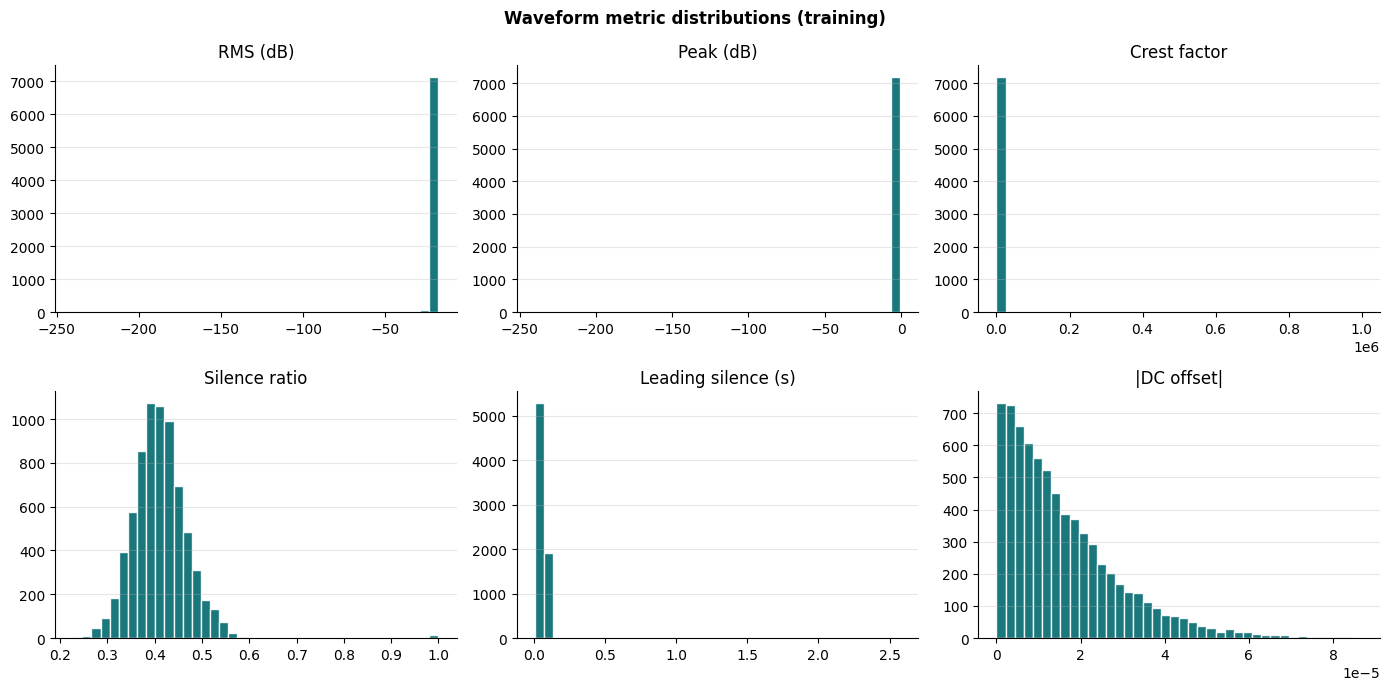


wave_rms_db extremes (low):
    class_name              filename  wave_rms_db
C_diminished_4 C_diminished_4-48.ogg       -240.0
C_diminished_4 C_diminished_4-49.ogg       -240.0
C_diminished_4 C_diminished_4-50.ogg       -240.0
C_diminished_4 C_diminished_4-51.ogg       -240.0
C_diminished_4 C_diminished_4-52.ogg       -240.0

wave_peak extremes (high):
     class_name                filename  wave_peak
A#_diminished_4 A#_diminished_4-110.ogg   0.922882
      F_minor_4         F_minor_4-8.ogg   0.915863
      D_minor_4       D_minor_4-181.ogg   0.914886
      A_minor_4        A_minor_4-30.ogg   0.913818
      C_minor_4        C_minor_4-78.ogg   0.913483

wave_silence_ratio extremes (high):
    class_name              filename  wave_silence_ratio
C_diminished_4 C_diminished_4-48.ogg                 1.0
C_diminished_4 C_diminished_4-49.ogg                 1.0
C_diminished_4 C_diminished_4-50.ogg                 1.0
C_diminished_4 C_diminished_4-51.ogg                 1.0
C_diminished_4 

In [22]:
# Waveform summary + flag rates
w = wave_df[wave_df["wave_ok"]].copy()
wave_cols = [
    "wave_peak", "wave_peak_db", "wave_rms_db", "wave_crest",
    "wave_dc_abs", "wave_silence_ratio", "wave_lead_silence_s",
    "wave_trail_silence_s", "wave_active_s", "wave_clip_frac", "wave_zcr",
]
wave_stats = w[wave_cols].agg(["mean", "std", "min", lambda s: s.quantile(0.01), "median", lambda s: s.quantile(0.99), "max"]).T
wave_stats.columns = ["mean", "std", "min", "p01", "median", "p99", "max"]

display(Markdown("### Waveform level stats"))
display(wave_stats.round(5))

display(Markdown("### Sample rates / channels"))
display(w["wave_sr"].value_counts().rename_axis("sr").reset_index(name="n"))
display(w["wave_channels"].value_counts().rename_axis("channels").reset_index(name="n"))

# Integrity flags (tunable thresholds)
flags = pd.DataFrame({
    "class_name": wave_df["class_name"],
    "filename": wave_df["filename"],
})
flags["flag_read_fail"] = ~wave_df["wave_ok"]
flags["flag_clip"] = wave_df["wave_clip_frac"].fillna(0) > 0.001
flags["flag_near_clip"] = wave_df["wave_peak"].fillna(0) >= 0.95
flags["flag_too_quiet"] = wave_df["wave_rms_db"].fillna(-999) < -40
flags["flag_too_loud"] = wave_df["wave_rms_db"].fillna(-999) > -6
flags["flag_dc"] = wave_df["wave_dc_abs"].fillna(0) > 0.02
flags["flag_mostly_silent"] = wave_df["wave_silence_ratio"].fillna(0) > 0.5
flags["flag_long_lead_silence"] = wave_df["wave_lead_silence_s"].fillna(0) > 0.5
flags["flag_short_active"] = wave_df["wave_active_s"].fillna(0) < 1.0
flags["flag_sr_mismatch"] = wave_df["wave_sr"].fillna(0) != AUDIO_SAMPLE_RATE

flag_cols = [c for c in flags.columns if c.startswith("flag_")]
flag_rates = (
    flags[flag_cols].sum().rename("n").to_frame()
    .assign(rate=lambda x: x["n"] / len(flags))
    .sort_values("n", ascending=False)
    .reset_index(names="flag")
)
display(Markdown("### Waveform flag rates"))
display(flag_rates)

# Plots
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
plot_specs = [
    ("wave_rms_db", "RMS (dB)"),
    ("wave_peak_db", "Peak (dB)"),
    ("wave_crest", "Crest factor"),
    ("wave_silence_ratio", "Silence ratio"),
    ("wave_lead_silence_s", "Leading silence (s)"),
    ("wave_dc_abs", "|DC offset|"),
]
for ax, (col, title) in zip(axes.ravel(), plot_specs):
    ax.hist(w[col], bins=40, color="#01696f", edgecolor="white", alpha=0.9)
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Waveform metric distributions (training)", fontweight="bold")
plt.tight_layout()
plt.show()

# Extremes
def extremes_table(col, n=5, ascending=True):
    sub = w.nsmallest(n, col) if ascending else w.nlargest(n, col)
    return sub[["class_name", "filename", col]].reset_index(drop=True)

display(Markdown("### Extreme samples"))
display(Markdown("**Lowest RMS (dB)**"))
display(extremes_table("wave_rms_db", ascending=True))
display(Markdown("**Highest peak**"))
display(extremes_table("wave_peak", ascending=False))
display(Markdown("**Highest silence ratio**"))
display(extremes_table("wave_silence_ratio", ascending=False))
display(Markdown("**Highest |DC|**"))
display(extremes_table("wave_dc_abs", ascending=False))
display(Markdown("**Longest lead silence**"))
display(extremes_table("wave_lead_silence_s", ascending=False))

## 3. CQT spectral metrics (from cached NPZ)

Uses the dataset CQT cache at `FEATURES_PATH` (extract with `cqt-extraction.ipynb` if missing).
No re-extraction. Metrics: energy, dynamic range, band energy (C3–C5 vs out-of-band),
chroma entropy, and **chord-tone purity** vs the file label (theory template check).

In [23]:
NOTE_TO_PC = {
    "C": 0, "C#": 1, "D": 2, "D#": 3, "E": 4, "F": 5,
    "F#": 6, "G": 7, "G#": 8, "A": 9, "A#": 10, "B": 11,
}
QUALITY_INTERVALS = {
    "major": (0, 4, 7),
    "minor": (0, 3, 7),
    "diminished": (0, 3, 6),
}


def chord_pitch_classes(root: str, quality: str):
    r = NOTE_TO_PC[root]
    return {(r + i) % 12 for i in QUALITY_INTERVALS[quality]}


def compute_cqt_metrics(features: np.ndarray, labels: np.ndarray, meta_df: pd.DataFrame) -> pd.DataFrame:
    """Vectorized per-sample stats on CQT dB tensors (N, bins, frames)."""
    N, n_bins, n_frames = features.shape
    assert N == len(meta_df)

    power = np.power(10.0, features / 10.0)  # (N, B, T)

    mean_db = features.mean(axis=(1, 2))
    std_db = features.std(axis=(1, 2))
    max_db = features.max(axis=(1, 2))
    min_db = features.min(axis=(1, 2))

    frame_mean = features.mean(axis=1)  # (N, T)
    frame_power = power.mean(axis=1)  # (N, T)
    total_power = frame_power.sum(axis=1) + 1e-12

    mid = n_frames // 2
    early_power_frac = frame_power[:, :mid].sum(axis=1) / total_power
    late_power_frac = frame_power[:, mid:].sum(axis=1) / total_power

    near_floor = (frame_mean <= (CQT_FLOOR_DB + 5)).mean(axis=1)
    frame_dyn = frame_mean.max(axis=1) - frame_mean.min(axis=1)

    bin_freqs = librosa.cqt_frequencies(
        n_bins=n_bins, fmin=CQT_FMIN, bins_per_octave=CQT_BINS_PER_OCTAVE
    )
    bin_midi = librosa.hz_to_midi(bin_freqs)
    c3, c5 = librosa.note_to_midi("C3"), librosa.note_to_midi("C5")
    band_mask = (bin_midi >= c3) & (bin_midi <= c5)
    low_mask = bin_midi < c3
    high_mask = bin_midi > c5

    bin_power = power.mean(axis=2)  # (N, B)
    low_e = bin_power[:, low_mask].sum(axis=1)
    band_e = bin_power[:, band_mask].sum(axis=1)
    high_e = bin_power[:, high_mask].sum(axis=1)
    tot_e = low_e + band_e + high_e + 1e-12

    bins_per_note = CQT_BINS_PER_OCTAVE // 12
    pc_index = (np.arange(n_bins) // bins_per_note) % 12
    chroma = np.zeros((N, 12), dtype=np.float64)
    for pc in range(12):
        chroma[:, pc] = bin_power[:, pc_index == pc].sum(axis=1)
    chroma_sum = chroma.sum(axis=1, keepdims=True) + 1e-12
    chroma_n = chroma / chroma_sum
    chroma_entropy = -(chroma_n * np.log(chroma_n + 1e-12)).sum(axis=1) / np.log(12)
    top1_frac = chroma_n.max(axis=1)
    top3_frac = np.sort(chroma_n, axis=1)[:, -3:].sum(axis=1)

    roots = meta_df["root"].to_numpy()
    quals = meta_df["quality"].to_numpy()
    purity = np.empty(N, dtype=np.float64)
    root_frac = np.empty(N, dtype=np.float64)
    est_root = np.empty(N, dtype=np.int32)
    template_best = np.empty(N, dtype=object)

    templates = {
        "major": np.array([0, 4, 7]),
        "minor": np.array([0, 3, 7]),
        "diminished": np.array([0, 3, 6]),
    }

    for i in range(N):
        pcs = chord_pitch_classes(roots[i], quals[i])
        purity[i] = chroma_n[i, list(pcs)].sum()
        root_pc = NOTE_TO_PC[roots[i]]
        root_frac[i] = chroma_n[i, root_pc]
        est_root[i] = int(np.argmax(chroma_n[i]))

        scores = {}
        for qname, iv in templates.items():
            pcs_q = (est_root[i] + iv) % 12
            scores[qname] = float(chroma_n[i, pcs_q].sum())
        template_best[i] = max(scores, key=scores.get)

    root_match = est_root == np.array([NOTE_TO_PC[r] for r in roots])
    centroid_hz = (bin_power * bin_freqs[None, :]).sum(axis=1) / (bin_power.sum(axis=1) + 1e-12)

    return pd.DataFrame(
        {
            "class_name": meta_df["class_name"].values,
            "filename": meta_df["filename"].values,
            "cqt_mean_db": mean_db,
            "cqt_std_db": std_db,
            "cqt_max_db": max_db,
            "cqt_min_db": min_db,
            "cqt_frame_dyn_db": frame_dyn,
            "cqt_near_floor_frac": near_floor,
            "cqt_early_power_frac": early_power_frac,
            "cqt_late_power_frac": late_power_frac,
            "cqt_low_frac": low_e / tot_e,
            "cqt_band_frac": band_e / tot_e,
            "cqt_high_frac": high_e / tot_e,
            "cqt_centroid_hz": centroid_hz,
            "cqt_chroma_entropy": chroma_entropy,
            "cqt_top1_frac": top1_frac,
            "cqt_top3_frac": top3_frac,
            "cqt_chord_purity": purity,
            "cqt_root_frac": root_frac,
            "cqt_est_root_pc": est_root,
            "cqt_root_match": root_match,
            "cqt_template_best": template_best,
            "cqt_quality_match": template_best == quals,
        }
    )


npz = np.load(FEATURES_PATH)
features = np.asarray(npz["features"])
labels = np.asarray(npz["labels"])

load_info = pd.DataFrame([
    {"key": "features_shape", "value": str(features.shape)},
    {"key": "labels_shape", "value": str(labels.shape)},
    {"key": "label_order_matches_inventory", "value": bool(np.array_equal(labels, df["class_name"].to_numpy()))},
])
display(load_info)
if not bool(load_info.loc[load_info.key == "label_order_matches_inventory", "value"].iloc[0]):
    raise RuntimeError("NPZ label order does not match training inventory order. Refusing to join metrics.")

cqt_df = compute_cqt_metrics(features, labels, df)

key_cols = ["cqt_chord_purity", "cqt_root_frac", "cqt_band_frac", "cqt_chroma_entropy"]
display(Markdown("### Core CQT metrics describe"))
display(cqt_df[key_cols].describe().round(4))

match_rates = pd.DataFrame([
    {"metric": "root_match_rate", "value": float(cqt_df["cqt_root_match"].mean())},
    {"metric": "quality_template_match_rate", "value": float(cqt_df["cqt_quality_match"].mean())},
])
display(Markdown("### Label ↔ chroma agreement"))
display(match_rates)

CQT features: (7200, 216, 188)  labels: (7200,)
NPZ ↔ inventory label order: OK


       cqt_chord_purity  cqt_root_frac  cqt_band_frac  cqt_chroma_entropy
count         7200.0000      7200.0000      7200.0000           7200.0000
mean             0.7116         0.1964         0.7201              0.7417
std              0.0747         0.1024         0.0764              0.0622
min              0.2500         0.0338         0.3380              0.5832
25%              0.6623         0.1253         0.6645              0.6927
50%              0.7189         0.1643         0.7310              0.7368
75%              0.7781         0.2645         0.7754              0.7866
max              0.8430         0.5543         0.8915              1.0000
root match rate: 21.694%
quality template match rate: 51.264%


=== CQT / label metrics ===
cqt_chord_purity          mean=0.7116  p01=0.5540  p50=0.7189  p99=0.8210
cqt_root_frac             mean=0.1964  p01=0.0472  p50=0.1643  p99=0.4554
cqt_band_frac             mean=0.7201  p01=0.5414  p50=0.7310  p99=0.8590
cqt_low_frac              mean=0.0018  p01=0.0002  p50=0.0007  p99=0.0079
cqt_high_frac             mean=0.2781  p01=0.1407  p50=0.2683  p99=0.4550
cqt_chroma_entropy        mean=0.7417  p01=0.6334  p50=0.7368  p99=0.8805
cqt_top3_frac             mean=0.7156  p01=0.5634  p50=0.7201  p99=0.8210
cqt_early_power_frac      mean=0.9839  p01=0.9635  p50=0.9862  p99=0.9954
cqt_near_floor_frac       mean=0.0002  p01=0.0000  p50=0.0000  p99=0.0000
cqt_centroid_hz           mean=467.0410  p01=380.9004  p50=459.6302  p99=572.6683
cqt_frame_dyn_db          mean=29.9933  p01=25.5144  p50=29.9034  p99=35.4079

quality match rate by true quality:
quality
diminished    0.5225
major         0.5917
minor         0.4238

root match rate by true quality:
qual

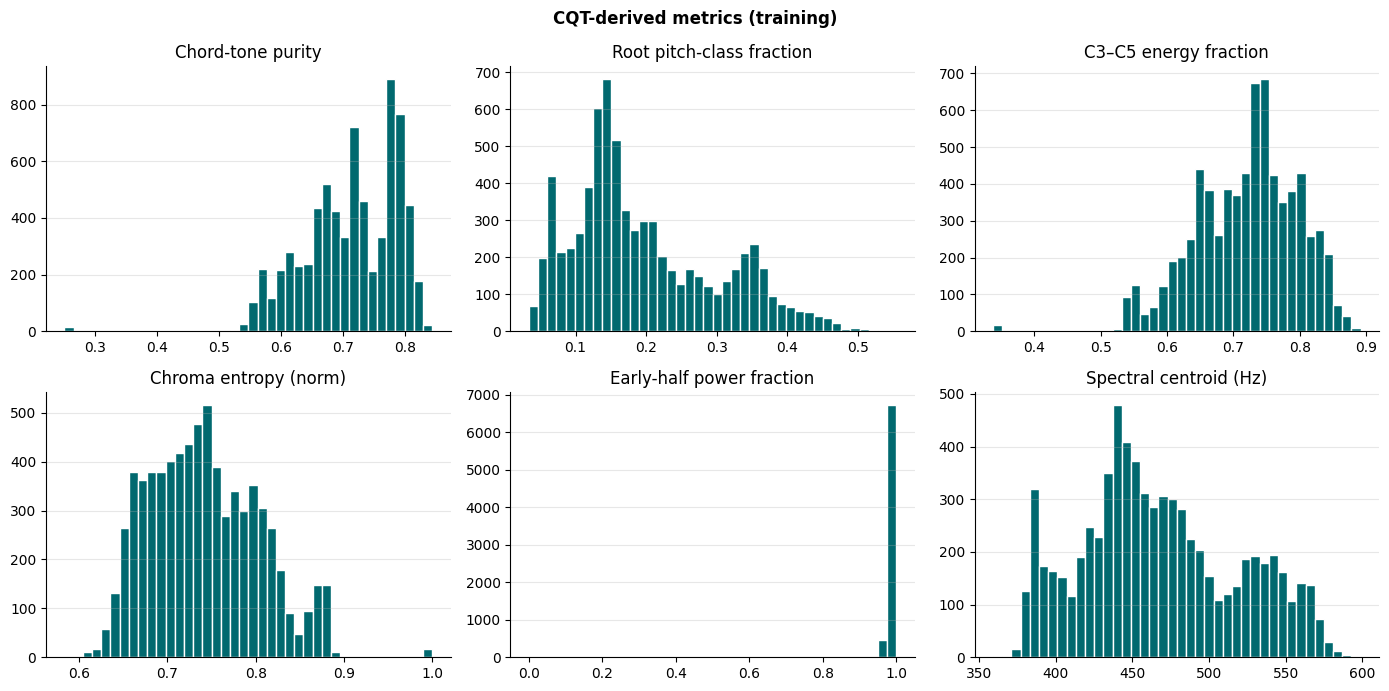


lowest mean chord purity classes:
                   mean     std     min
class_name                             
C_diminished_4   0.5517  0.0920  0.2500
C#_diminished_4  0.5682  0.0079  0.5432
C_minor_4        0.6045  0.0385  0.5137
E_diminished_4   0.6081  0.0115  0.5804
D_diminished_4   0.6137  0.0118  0.5704
C_major_4        0.6294  0.0524  0.5358
D_minor_4        0.6454  0.0252  0.5970
D#_diminished_4  0.6549  0.0085  0.6263

highest mean chord purity classes:
              mean     std     min
class_name                        
B_major_4   0.7861  0.0204  0.7501
F#_major_4  0.7867  0.0187  0.7443
G_major_4   0.7884  0.0099  0.7534
G#_minor_4  0.7903  0.0132  0.7506
A_minor_4   0.7918  0.0124  0.7553
G#_major_4  0.7961  0.0150  0.7532
A_major_4   0.7980  0.0132  0.7658
B_minor_4   0.8112  0.0127  0.7703


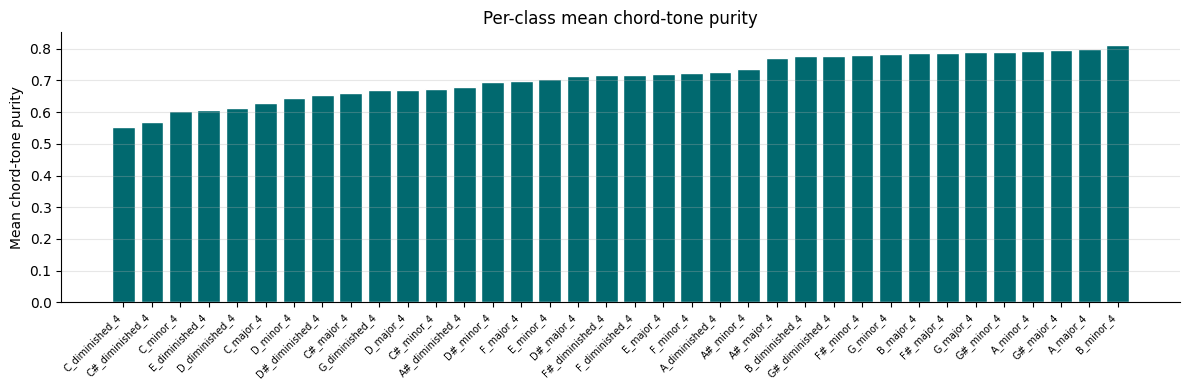


lowest purity samples:
    class_name              filename  cqt_chord_purity  cqt_root_frac cqt_template_best
C_diminished_4 C_diminished_4-48.ogg              0.25       0.083333             major
C_diminished_4 C_diminished_4-49.ogg              0.25       0.083333             major
C_diminished_4 C_diminished_4-50.ogg              0.25       0.083333             major
C_diminished_4 C_diminished_4-51.ogg              0.25       0.083333             major
C_diminished_4 C_diminished_4-52.ogg              0.25       0.083333             major
C_diminished_4 C_diminished_4-53.ogg              0.25       0.083333             major
C_diminished_4 C_diminished_4-54.ogg              0.25       0.083333             major
C_diminished_4 C_diminished_4-55.ogg              0.25       0.083333             major
C_diminished_4 C_diminished_4-56.ogg              0.25       0.083333             major
C_diminished_4 C_diminished_4-57.ogg              0.25       0.083333             major


In [24]:
# CQT distributions + label-consistency views
cqt_stat_cols = [
    "cqt_chord_purity", "cqt_root_frac", "cqt_band_frac", "cqt_low_frac", "cqt_high_frac",
    "cqt_chroma_entropy", "cqt_top3_frac", "cqt_early_power_frac", "cqt_near_floor_frac",
    "cqt_centroid_hz", "cqt_frame_dyn_db",
]
cqt_stats = cqt_df[cqt_stat_cols].agg(
    ["mean", lambda s: s.quantile(0.01), "median", lambda s: s.quantile(0.99)]
).T
cqt_stats.columns = ["mean", "p01", "median", "p99"]

display(Markdown("### CQT metric percentiles"))
display(cqt_stats.round(4))

match_by_quality = pd.DataFrame({
    "quality_match_rate": cqt_df.groupby(df["quality"])["cqt_quality_match"].mean(),
    "root_match_rate": cqt_df.groupby(df["quality"])["cqt_root_match"].mean(),
}).round(4)
display(Markdown("### Match rates by true quality"))
display(match_by_quality)

ct = pd.crosstab(df["quality"], cqt_df["cqt_template_best"], normalize="index").round(3)
display(Markdown("### Template-best quality vs label (row-normalized)"))
display(ct)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col, title in zip(
    axes.ravel(),
    [
        "cqt_chord_purity", "cqt_root_frac", "cqt_band_frac",
        "cqt_chroma_entropy", "cqt_early_power_frac", "cqt_centroid_hz",
    ],
    [
        "Chord-tone purity", "Root pitch-class fraction", "C3–C5 energy fraction",
        "Chroma entropy (norm)", "Early-half power fraction", "Spectral centroid (Hz)",
    ],
):
    ax.hist(cqt_df[col], bins=40, color="#01696f", edgecolor="white")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("CQT-derived metrics (training)", fontweight="bold")
plt.tight_layout()
plt.show()

cls_purity = (
    cqt_df.groupby("class_name")["cqt_chord_purity"]
    .agg(["mean", "std", "min"])
    .sort_values("mean")
    .round(4)
)
display(Markdown("### Lowest mean chord purity classes"))
display(cls_purity.head(8))
display(Markdown("### Highest mean chord purity classes"))
display(cls_purity.tail(8))

fig, ax = plt.subplots(figsize=(12, 4))
order = cls_purity.index.tolist()
ax.bar(range(len(order)), cls_purity.loc[order, "mean"], color="#01696f", edgecolor="white")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Mean chord-tone purity")
ax.set_title("Per-class mean chord-tone purity")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(Markdown("### Lowest purity samples"))
display(
    cqt_df.nsmallest(10, "cqt_chord_purity")[
        ["class_name", "filename", "cqt_chord_purity", "cqt_root_frac", "cqt_template_best"]
    ].reset_index(drop=True)
)

## 4. Merge metrics, outliers, near-duplicates

Combine duration + waveform + CQT into one table, score multivariate outliers
(class-conditional z-scores on key scalars), and find within-training near-duplicate
CQT fingerprints (cosine similarity on mean-pooled CQT).

digital silence / empty audio: 16 (0.22%)
    class_name              filename  duration_s  wave_peak  wave_rms_db
C_diminished_4 C_diminished_4-48.ogg         2.2        0.0       -240.0
C_diminished_4 C_diminished_4-49.ogg         2.5        0.0       -240.0
C_diminished_4 C_diminished_4-50.ogg         2.5        0.0       -240.0
C_diminished_4 C_diminished_4-51.ogg         2.4        0.0       -240.0
C_diminished_4 C_diminished_4-52.ogg         2.5        0.0       -240.0
C_diminished_4 C_diminished_4-53.ogg         2.2        0.0       -240.0
C_diminished_4 C_diminished_4-54.ogg         2.5        0.0       -240.0
C_diminished_4 C_diminished_4-55.ogg         2.4        0.0       -240.0
C_diminished_4 C_diminished_4-56.ogg         2.4        0.0       -240.0
C_diminished_4 C_diminished_4-57.ogg         2.5        0.0       -240.0
C_diminished_4 C_diminished_4-58.ogg         2.5        0.0       -240.0
C_diminished_4 C_diminished_4-59.ogg         2.4        0.0       -240.0
C_diminis

outlier_score (valid): mean=0.746  p99 thr=1.531
flagged top 1% (excl. silence): 72

Top outlier samples (excl. digital silence):
     class_name               filename  outlier_score  outlier_top_feature  duration_s  wave_rms_db  cqt_chord_purity  cqt_root_frac
 C_diminished_4  C_diminished_4-64.ogg        32.1942 cqt_early_power_frac         2.3     -43.9240            0.4860         0.1114
 C_diminished_4  C_diminished_4-69.ogg         3.9154   wave_silence_ratio         2.5     -21.7791            0.6386         0.0485
 C_diminished_4  C_diminished_4-47.ogg         3.3714   wave_silence_ratio         2.4     -20.5639            0.5171         0.0783
 A_diminished_4  A_diminished_4-49.ogg         2.1981            wave_peak         2.6     -21.2675            0.7388         0.3937
F#_diminished_4 F#_diminished_4-85.ogg         2.1887   cqt_chroma_entropy         2.2     -21.8975            0.7416         0.3079
 A_diminished_4  A_diminished_4-26.ogg         2.1807            wave_pe

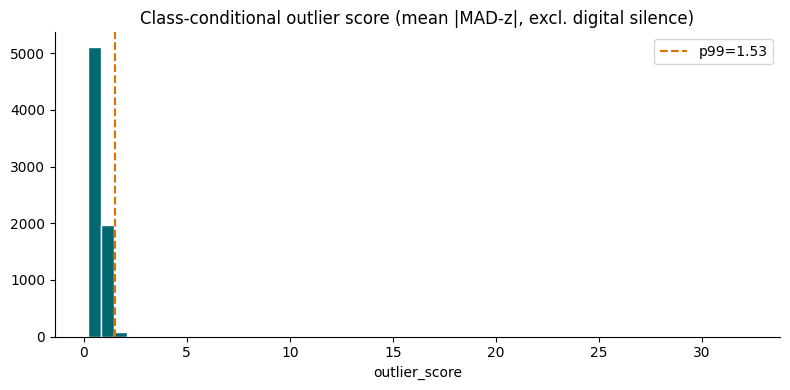

Saved metrics → ../datasets/training-sample-metrics.pkl  shape=(7200, 64)


In [28]:
# --- Merge all metrics ---
metrics = df[
    ["class_name", "filename", "duration_s", "root", "quality", "octave", "file_idx", "audio_path"]
].copy()
metrics["npz_index"] = np.arange(len(metrics))

wave_merge = wave_df.drop(columns=[c for c in ("class_name", "filename") if c in wave_df.columns], errors="ignore")
cqt_merge = cqt_df.drop(columns=[c for c in ("class_name", "filename") if c in cqt_df.columns], errors="ignore")
metrics = pd.concat(
    [metrics.reset_index(drop=True), wave_merge.reset_index(drop=True), cqt_merge.reset_index(drop=True)],
    axis=1,
)

if "flags" in dir() and isinstance(flags, pd.DataFrame):
    for c in flag_cols:
        metrics[c] = flags[c].values

metrics["flag_digital_silence"] = (
    (~metrics["wave_ok"])
    | (metrics["wave_peak"].fillna(0) <= 1e-8)
    | (metrics["wave_rms_db"].fillna(-999) < -100)
)
metrics.loc[metrics["flag_digital_silence"], "wave_crest"] = np.nan
metrics.loc[metrics["wave_crest"] > 100, "wave_crest"] = 100

silence = metrics.loc[
    metrics["flag_digital_silence"],
    ["class_name", "filename", "duration_s", "wave_peak", "wave_rms_db"],
].reset_index(drop=True)
display(Markdown(f"### Digital silence / empty audio (**{len(silence)}** files)"))
display(silence if len(silence) else pd.DataFrame({"note": ["none"]}))

SCORE_COLS = [
    "duration_s",
    "wave_rms_db",
    "wave_peak",
    "wave_silence_ratio",
    "wave_lead_silence_s",
    "wave_dc_abs",
    "wave_crest",
    "cqt_chord_purity",
    "cqt_root_frac",
    "cqt_band_frac",
    "cqt_chroma_entropy",
    "cqt_early_power_frac",
    "cqt_near_floor_frac",
    "cqt_centroid_hz",
    "cqt_frame_dyn_db",
]


def mad_z(series: pd.Series) -> pd.Series:
    s = series.astype(float)
    med = s.median()
    mad = (s - med).abs().median()
    if not np.isfinite(mad) or mad < 1e-12:
        mad = s.std()
        if not np.isfinite(mad) or mad < 1e-12:
            return pd.Series(np.zeros(len(s)), index=s.index)
    z = 0.6745 * (s - med) / mad
    return z.replace([np.inf, -np.inf], np.nan).fillna(0.0)


z_parts = []
for cls, idx in metrics.groupby("class_name").groups.items():
    block = metrics.loc[idx, SCORE_COLS]
    z = block.apply(mad_z, axis=0)
    z_parts.append(z)

z_all = pd.concat(z_parts).sort_index()
outlier_score = z_all.abs().mean(axis=1)
metrics["outlier_score"] = outlier_score
metrics["outlier_max_abs_z"] = z_all.abs().max(axis=1)
metrics["outlier_top_feature"] = z_all.abs().idxmax(axis=1)

valid = ~metrics["flag_digital_silence"]
thr = metrics.loc[valid, "outlier_score"].quantile(0.99)
metrics["flag_outlier_top1pct"] = valid & (metrics["outlier_score"] >= thr)

outlier_summary = pd.DataFrame([
    {"metric": "outlier_score_mean_valid", "value": float(metrics.loc[valid, "outlier_score"].mean())},
    {"metric": "p99_threshold", "value": float(thr)},
    {"metric": "flagged_top1pct", "value": int(metrics["flag_outlier_top1pct"].sum())},
    {"metric": "digital_silence", "value": int(metrics["flag_digital_silence"].sum())},
])
display(Markdown("### Outlier score summary"))
display(outlier_summary)

display(Markdown("### Top outlier samples (excl. digital silence)"))
display(
    metrics.loc[valid]
    .nlargest(15, "outlier_score")[
        [
            "class_name", "filename", "outlier_score", "outlier_top_feature",
            "duration_s", "wave_rms_db", "cqt_chord_purity", "cqt_root_frac",
        ]
    ]
    .round(4)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(metrics.loc[valid, "outlier_score"], bins=50, color="#01696f", edgecolor="white")
ax.axvline(thr, color="#da7101", linestyle="--", label=f"p99={thr:.2f}")
ax.set_title("Class-conditional outlier score (mean |MAD-z|, excl. digital silence)")
ax.set_xlabel("outlier_score")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

metrics.to_pickle(METRICS_PATH)
display(Markdown(f"Saved metrics → `{METRICS_PATH}`  shape=**{metrics.shape}**"))

exact CQT duplicate groups: 13
samples in exact-dup groups: 40
  n=2  classes=['A#_major_4']
class_name           filename
A#_major_4 A#_major_4-169.ogg
A#_major_4  A#_major_4-34.ogg
  n=2  classes=['A#_major_4']
class_name           filename
A#_major_4 A#_major_4-121.ogg
A#_major_4  A#_major_4-65.ogg
  n=2  classes=['A#_major_4']
class_name          filename
A#_major_4  A#_major_4-3.ogg
A#_major_4 A#_major_4-89.ogg
  n=2  classes=['A#_major_4']
class_name           filename
A#_major_4 A#_major_4-125.ogg
A#_major_4  A#_major_4-63.ogg
  n=16  classes=['C_diminished_4']
    class_name              filename
C_diminished_4 C_diminished_4-48.ogg
C_diminished_4 C_diminished_4-49.ogg
C_diminished_4 C_diminished_4-50.ogg
C_diminished_4 C_diminished_4-51.ogg
C_diminished_4 C_diminished_4-52.ogg
C_diminished_4 C_diminished_4-53.ogg
C_diminished_4 C_diminished_4-54.ogg
C_diminished_4 C_diminished_4-55.ogg
  n=2  classes=['A#_major_4']
class_name           filename
A#_major_4  A#_major_4-12.ogg
A#


=== Residual NN cosine similarity (excl. silence) ===
count    7200.00000
mean        0.58265
std         0.13981
min         0.30238
50%         0.55892
90%         0.78104
95%         0.85051
99%         0.94085
99.9%       1.00000
max         1.00000
same-class NN rate: 39.833%

pairs with residual cosine sim ≥ 0.999: 14
  same-class: 14  cross-class: 0
    class_name              filename       nn_class           nn_filename  nn_cosine_sim  nn_same_class
C_diminished_4 C_diminished_4-53.ogg C_diminished_4 C_diminished_4-56.ogg            1.0           True
C_diminished_4 C_diminished_4-52.ogg C_diminished_4 C_diminished_4-56.ogg            1.0           True
C_diminished_4 C_diminished_4-51.ogg C_diminished_4 C_diminished_4-56.ogg            1.0           True
C_diminished_4 C_diminished_4-50.ogg C_diminished_4 C_diminished_4-56.ogg            1.0           True
C_diminished_4 C_diminished_4-49.ogg C_diminished_4 C_diminished_4-56.ogg            1.0           True
C_diminished_4 C

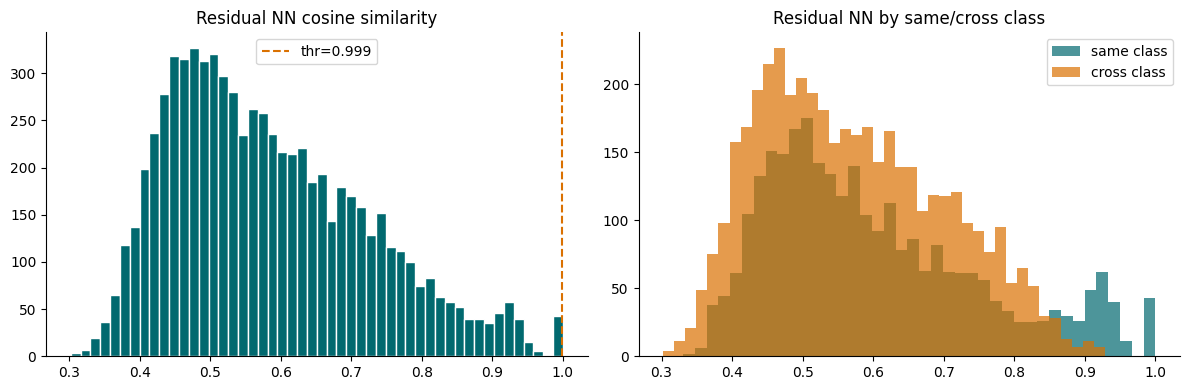


Updated metrics cache: ../datasets/training-sample-metrics.pkl


In [30]:
# --- Within-training near-duplicates ---
# Mean-pooled raw CQT cosine is too saturated (all piano chords look alike).
# Use: (1) exact CQT equality, (2) class-mean residual fingerprints.

from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
import hashlib

flat = features.reshape(len(features), -1)

def row_hash(row: np.ndarray) -> str:
    return hashlib.md5(np.ascontiguousarray(row).tobytes()).hexdigest()

hashes = [row_hash(flat[i]) for i in range(len(flat))]
metrics["cqt_hash"] = hashes
hash_counts = metrics["cqt_hash"].value_counts()
dup_hashes = set(hash_counts[hash_counts > 1].index)
metrics["flag_exact_cqt_dup"] = metrics["cqt_hash"].isin(dup_hashes)

dup_summary = pd.DataFrame([
    {"metric": "exact_cqt_dup_groups", "value": len(dup_hashes)},
    {"metric": "samples_in_exact_dup_groups", "value": int(metrics["flag_exact_cqt_dup"].sum())},
])
display(Markdown("### Exact CQT duplicates"))
display(dup_summary)

if dup_hashes:
    groups = []
    for h, g in metrics[metrics.flag_exact_cqt_dup].groupby("cqt_hash"):
        groups.append({
            "n": len(g),
            "classes": ", ".join(sorted(g.class_name.unique())),
            "files": ", ".join(g.filename.head(6).tolist()) + (" …" if len(g) > 6 else ""),
        })
    display(pd.DataFrame(groups).sort_values("n", ascending=False).reset_index(drop=True))
    display(Markdown("#### Full exact-dup sample list"))
    display(
        metrics.loc[metrics.flag_exact_cqt_dup, ["class_name", "filename", "cqt_hash"]]
        .sort_values(["cqt_hash", "filename"])
        .reset_index(drop=True)
    )

# Residual fingerprint: x - class_mean, then L2-normalize
resid = np.zeros_like(features.mean(axis=2), dtype=np.float64)
pooled = features.mean(axis=2).astype(np.float64)
for cls, idx in metrics.groupby("class_name").groups.items():
    idx = np.asarray(list(idx))
    mu = pooled[idx].mean(axis=0, keepdims=True)
    resid[idx] = pooled[idx] - mu

n_blocks = 4
block_len = features.shape[2] // n_blocks
bins_per_note = CQT_BINS_PER_OCTAVE // 12
n_bins = features.shape[1]
pc_index = (np.arange(n_bins) // bins_per_note) % 12
time_chroma = np.zeros((len(features), n_blocks * 12), dtype=np.float64)
power = np.power(10.0, features / 10.0)
for b in range(n_blocks):
    sl = power[:, :, b * block_len : (b + 1) * block_len].mean(axis=2)
    for pc in range(12):
        time_chroma[:, b * 12 + pc] = sl[:, pc_index == pc].sum(axis=1)

time_resid = np.zeros_like(time_chroma)
for cls, idx in metrics.groupby("class_name").groups.items():
    idx = np.asarray(list(idx))
    mu = time_chroma[idx].mean(axis=0, keepdims=True)
    time_resid[idx] = time_chroma[idx] - mu

fingerprints = np.concatenate([resid, time_resid], axis=1)
fingerprints = normalize(fingerprints, norm="l2", axis=1)
zero_fp = np.linalg.norm(fingerprints, axis=1) < 1e-8

nn = NearestNeighbors(n_neighbors=2, metric="cosine", algorithm="brute")
nn.fit(fingerprints)
dists, idxs = nn.kneighbors(fingerprints, return_distance=True)
metrics["nn_index"] = idxs[:, 1]
metrics["nn_cosine_dist"] = dists[:, 1]
metrics["nn_cosine_sim"] = 1.0 - dists[:, 1]
metrics.loc[zero_fp, "nn_cosine_sim"] = np.nan
metrics["nn_class"] = metrics.loc[metrics["nn_index"].values, "class_name"].to_numpy()
metrics["nn_filename"] = metrics.loc[metrics["nn_index"].values, "filename"].to_numpy()
metrics["nn_same_class"] = metrics["nn_class"].to_numpy() == metrics["class_name"].to_numpy()

valid_nn = metrics["nn_cosine_sim"].notna()
nn_desc = metrics.loc[valid_nn, "nn_cosine_sim"].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]
).to_frame("nn_cosine_sim")
nn_meta = pd.DataFrame([
    {"metric": "same_class_nn_rate", "value": float(metrics.loc[valid_nn, "nn_same_class"].mean())},
    {"metric": "valid_nn_samples", "value": int(valid_nn.sum())},
])
display(Markdown("### Residual NN cosine similarity"))
display(nn_desc)
display(nn_meta)

SIM_THR = 0.999
high = metrics[valid_nn & (metrics["nn_cosine_sim"] >= SIM_THR)].copy()
pair_mask = high["npz_index"] < high["nn_index"]
pairs = high.loc[
    pair_mask,
    ["class_name", "filename", "nn_class", "nn_filename", "nn_cosine_sim", "nn_same_class"],
].sort_values("nn_cosine_sim", ascending=False).reset_index(drop=True)
metrics["flag_near_dup"] = valid_nn & (metrics["nn_cosine_sim"] >= SIM_THR)

pair_summary = pd.DataFrame([
    {"metric": f"pairs_sim_ge_{SIM_THR}", "value": len(pairs)},
    {"metric": "same_class_pairs", "value": int(pairs["nn_same_class"].sum()) if len(pairs) else 0},
    {"metric": "cross_class_pairs", "value": int((~pairs["nn_same_class"]).sum()) if len(pairs) else 0},
])
display(Markdown(f"### Near-duplicate pairs (residual sim ≥ {SIM_THR})"))
display(pair_summary)
if len(pairs):
    display(pairs.head(25))
else:
    display(Markdown("_None at this threshold._"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(metrics.loc[valid_nn, "nn_cosine_sim"], bins=50, color="#01696f", edgecolor="white")
axes[0].axvline(SIM_THR, color="#da7101", linestyle="--", label=f"thr={SIM_THR}")
axes[0].set_title("Residual NN cosine similarity")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

same = metrics.loc[valid_nn & metrics["nn_same_class"], "nn_cosine_sim"]
cross = metrics.loc[valid_nn & ~metrics["nn_same_class"], "nn_cosine_sim"]
axes[1].hist(same, bins=40, alpha=0.7, label="same class", color="#01696f")
axes[1].hist(cross, bins=40, alpha=0.7, label="cross class", color="#da7101")
axes[1].set_title("Residual NN by same/cross class")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

metrics.to_pickle(METRICS_PATH)
display(Markdown(f"Updated metrics cache: `{METRICS_PATH}`"))

## 5. Conclusions & action list

Aggregate integrity flags into a single review table. Interpret results for
training-set validity (duration, levels, label-spectrum agreement, clones).

In [31]:
# Aggregate flags
metrics["flag_low_purity"] = metrics["cqt_chord_purity"] < metrics.loc[
    ~metrics["flag_digital_silence"], "cqt_chord_purity"
].quantile(0.01)
metrics["flag_root_mismatch"] = ~metrics["cqt_root_match"]
metrics["flag_quality_mismatch"] = ~metrics["cqt_quality_match"]
metrics["flag_high_oob"] = (metrics["cqt_low_frac"] + metrics["cqt_high_frac"]) > 0.55

flag_like = [c for c in metrics.columns if c.startswith("flag_")]

# Actionable flags for review (exclude soft root/quality mismatch — chroma template is noisy)
ACTION_FLAGS = [
    "flag_digital_silence",
    "flag_read_fail",
    "flag_clip",
    "flag_near_clip",
    "flag_too_quiet",
    "flag_too_loud",
    "flag_dc",
    "flag_long_lead_silence",
    "flag_short_active",
    "flag_exact_cqt_dup",
    "flag_near_dup",
    "flag_low_purity",
    "flag_outlier_top1pct",
]
ACTION_FLAGS = [c for c in ACTION_FLAGS if c in metrics.columns]
metrics["n_action_flags"] = metrics[ACTION_FLAGS].sum(axis=1).astype(int)

flag_summary = (
    metrics[flag_like].sum().rename("n").to_frame()
    .assign(rate=lambda x: x["n"] / len(metrics))
    .sort_values("n", ascending=False)
    .reset_index(names="flag")
)
display(Markdown("### Full flag summary"))
display(flag_summary)

action_overview = pd.DataFrame([
    {"metric": "samples_any_action_flag", "n": int((metrics.n_action_flags > 0).sum()),
     "rate": float((metrics.n_action_flags > 0).mean())},
    {"metric": "samples_ge_2_action_flags", "n": int((metrics.n_action_flags >= 2).sum()),
     "rate": float((metrics.n_action_flags >= 2).mean())},
])
display(Markdown("### Actionable flag overview"))
display(action_overview)

review = metrics[metrics["n_action_flags"] > 0].sort_values(
    ["n_action_flags", "outlier_score"], ascending=False
)
show_cols = [
    "class_name", "filename", "n_action_flags", "outlier_score",
    "duration_s", "wave_rms_db", "wave_peak", "cqt_chord_purity",
] + ACTION_FLAGS
show_cols = [c for c in show_cols if c in review.columns]
display(Markdown("### Top multi-flag samples (actionable)"))
display(review[show_cols].head(40).round(4).reset_index(drop=True))

exclude = metrics.loc[
    metrics["flag_digital_silence"], ["class_name", "filename", "audio_path"]
].reset_index(drop=True)
display(Markdown(f"### Hard exclude candidates — digital silence (**{len(exclude)}**)"))
display(exclude)

# Headline conclusions as a compact table + short markdown
n_sil = int(metrics["flag_digital_silence"].sum())
n_exact = int(metrics["flag_exact_cqt_dup"].sum()) if "flag_exact_cqt_dup" in metrics else 0
n_near = int(metrics["flag_near_dup"].sum()) if "flag_near_dup" in metrics else 0
n_out = int(metrics["flag_outlier_top1pct"].sum())
non_sil = ~metrics["flag_digital_silence"]

conclusions = pd.DataFrame([
    {"area": "Inventory", "status": "CLEAN",
     "detail": f"{len(metrics)} files / {metrics.class_name.nunique()} classes / 200 each; naming OK"},
    {"area": "Duration", "status": "CLEAN",
     "detail": f"[{metrics.duration_s.min():.1f}, {metrics.duration_s.max():.1f}] s; all ≥ 2.0 s window"},
    {"area": "Digital silence", "status": "EXCLUDE",
     "detail": f"{n_sil} files — C_diminished_4 takes 48–63 (empty audio)"},
    {"area": "Clipping / DC", "status": "OK",
     "detail": "No clipping; DC negligible among non-silent"},
    {"area": "Chord-tone purity", "status": "OK",
     "detail": f"mean={metrics.loc[non_sil, 'cqt_chord_purity'].mean():.3f} (non-silent)"},
    {"area": "C3–C5 band energy", "status": "OK",
     "detail": f"mean fraction={metrics.loc[non_sil, 'cqt_band_frac'].mean():.2f}"},
    {"area": "Root/quality chroma match", "status": "WEAK DIAG",
     "detail": (
         f"root={metrics.loc[non_sil, 'cqt_root_match'].mean():.1%}, "
         f"quality={metrics.loc[non_sil, 'cqt_quality_match'].mean():.1%} — prefer purity + listen"
     )},
    {"area": "Exact CQT dups", "status": "REVIEW",
     "detail": f"{n_exact} samples (silence cluster + A#_major_4 clone pairs)"},
    {"area": "Residual near-dups", "status": "INFO",
     "detail": f"{n_near} samples at residual sim ≥ 0.999"},
    {"area": "Outliers top 1%", "status": "REVIEW",
     "detail": f"{n_out} samples (excl. silence) — spot-check, don't mass-delete"},
])
display(Markdown("### Conclusions"))
display(conclusions)

actions = pd.DataFrame([
    {"priority": 1, "action": "Drop or re-record C_diminished_4-{48..63}.ogg", "n": n_sil},
    {"priority": 2, "action": "Dedup A#_major_4 exact CQT pairs (keep one of each)", "n": max(n_exact - n_sil, 0)},
    {"priority": 3, "action": "Spot-check multi-flag + lowest-purity non-silent rows", "n": int((metrics.n_action_flags >= 2).sum())},
    {"priority": 4, "action": f"Metrics cache at {METRICS_PATH}", "n": len(metrics)},
])
display(Markdown("### Recommended actions"))
display(actions)

metrics.to_pickle(METRICS_PATH)
display(Markdown(f"Final metrics saved: `{METRICS_PATH}`  shape=**{metrics.shape}**"))

=== Flag summary (training) ===
flag_clip                           0  ( 0.00%)
flag_dc                             0  ( 0.00%)
flag_digital_silence               16  ( 0.22%)
flag_exact_cqt_dup                 40  ( 0.56%)
flag_high_oob                      16  ( 0.22%)
flag_long_lead_silence             17  ( 0.24%)
flag_low_purity                    88  ( 1.22%)
flag_mostly_silent                391  ( 5.43%)
flag_near_clip                      0  ( 0.00%)
flag_near_dup                      40  ( 0.56%)
flag_outlier_top1pct               72  ( 1.00%)
flag_quality_mismatch            3509  (48.74%)
flag_read_fail                      0  ( 0.00%)
flag_root_mismatch               5638  (78.31%)
flag_short_active                  17  ( 0.24%)
flag_sr_mismatch                    0  ( 0.00%)
flag_too_loud                       0  ( 0.00%)
flag_too_quiet                     17  ( 0.24%)

samples with any ACTION flag: 182 (2.53%)
samples with ≥2 ACTION flags: 42

Top multi-flag samples (act